<a href="https://colab.research.google.com/github/goalic/Programowanie2/blob/main/PROJEKT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
!wget https://github.com/goalic/Programowanie2/blob/main/Video_Game_Sales_as_of_Jan_2017.csv

--2026-06-07 14:32:30--  https://github.com/goalic/Programowanie2/blob/main/Video_Game_Sales_as_of_Jan_2017.csv
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Video_Game_Sales_as_of_Jan_2017.csv.1’

Video_Game_Sales_as     [ <=>                ] 224.15K  --.-KB/s    in 0.03s   

2026-06-07 14:32:31 (8.03 MB/s) - ‘Video_Game_Sales_as_of_Jan_2017.csv.1’ saved [229531]



In [76]:
import pandas as pd

csv_url = 'https://raw.githubusercontent.com/goalic/Programowanie2/main/Video_Game_Sales_as_of_Jan_2017.csv'

fred = pd.read_csv(csv_url)

fred.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


In [77]:
fred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17408 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17415 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     8336 non-null   float64
 11  Critic_Count     8336 non-null   float64
 12  User_Score       7798 non-null   float64
 13  User_Count       7798 non-null   float64
 14  Rating           10252 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB


In [78]:
fred.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,17408.000000,17416.000000,17416.000000,17416.000000,17416.000000,17416.000000,8336.000000,8336.000000,7798.000000,7798.000000
mean,2006.630859,0.254534,0.140727,0.075020,0.045908,0.516469,68.912548,26.192059,7.117056,162.672480
std,5.901598,0.800673,0.497341,0.303412,0.183932,1.526124,13.964937,18.991526,1.502410,562.837954
min,1976.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.050000,60.000000,11.000000,6.400000,10.000000
50%,2008.000000,0.070000,0.020000,0.000000,0.010000,0.160000,71.000000,21.000000,7.500000,25.000000
75%,2011.000000,0.230000,0.100000,0.030000,0.030000,0.450000,79.000000,36.000000,8.200000,81.000000
max,2017.000000,41.360000,28.960000,10.220000,10.570000,82.540000,98.000000,113.000000,9.700000,10766.000000


In [79]:
fred["Year_of_Release"].value_counts()

,count
Year_of_Release,
2009.0,1550
2008.0,1536
2010.0,1331
2007.0,1262
2011.0,1215
2006.0,1067
2005.0,968
2002.0,869
2003.0,801


In [80]:
fred["Global_Sales"].value_counts()

,count
Global_Sales,
0.01,1239
0.02,1107
0.03,848
0.04,670
0.05,622
...,...
4.70,1
4.68,1
4.67,1


WIZUALIZACJE

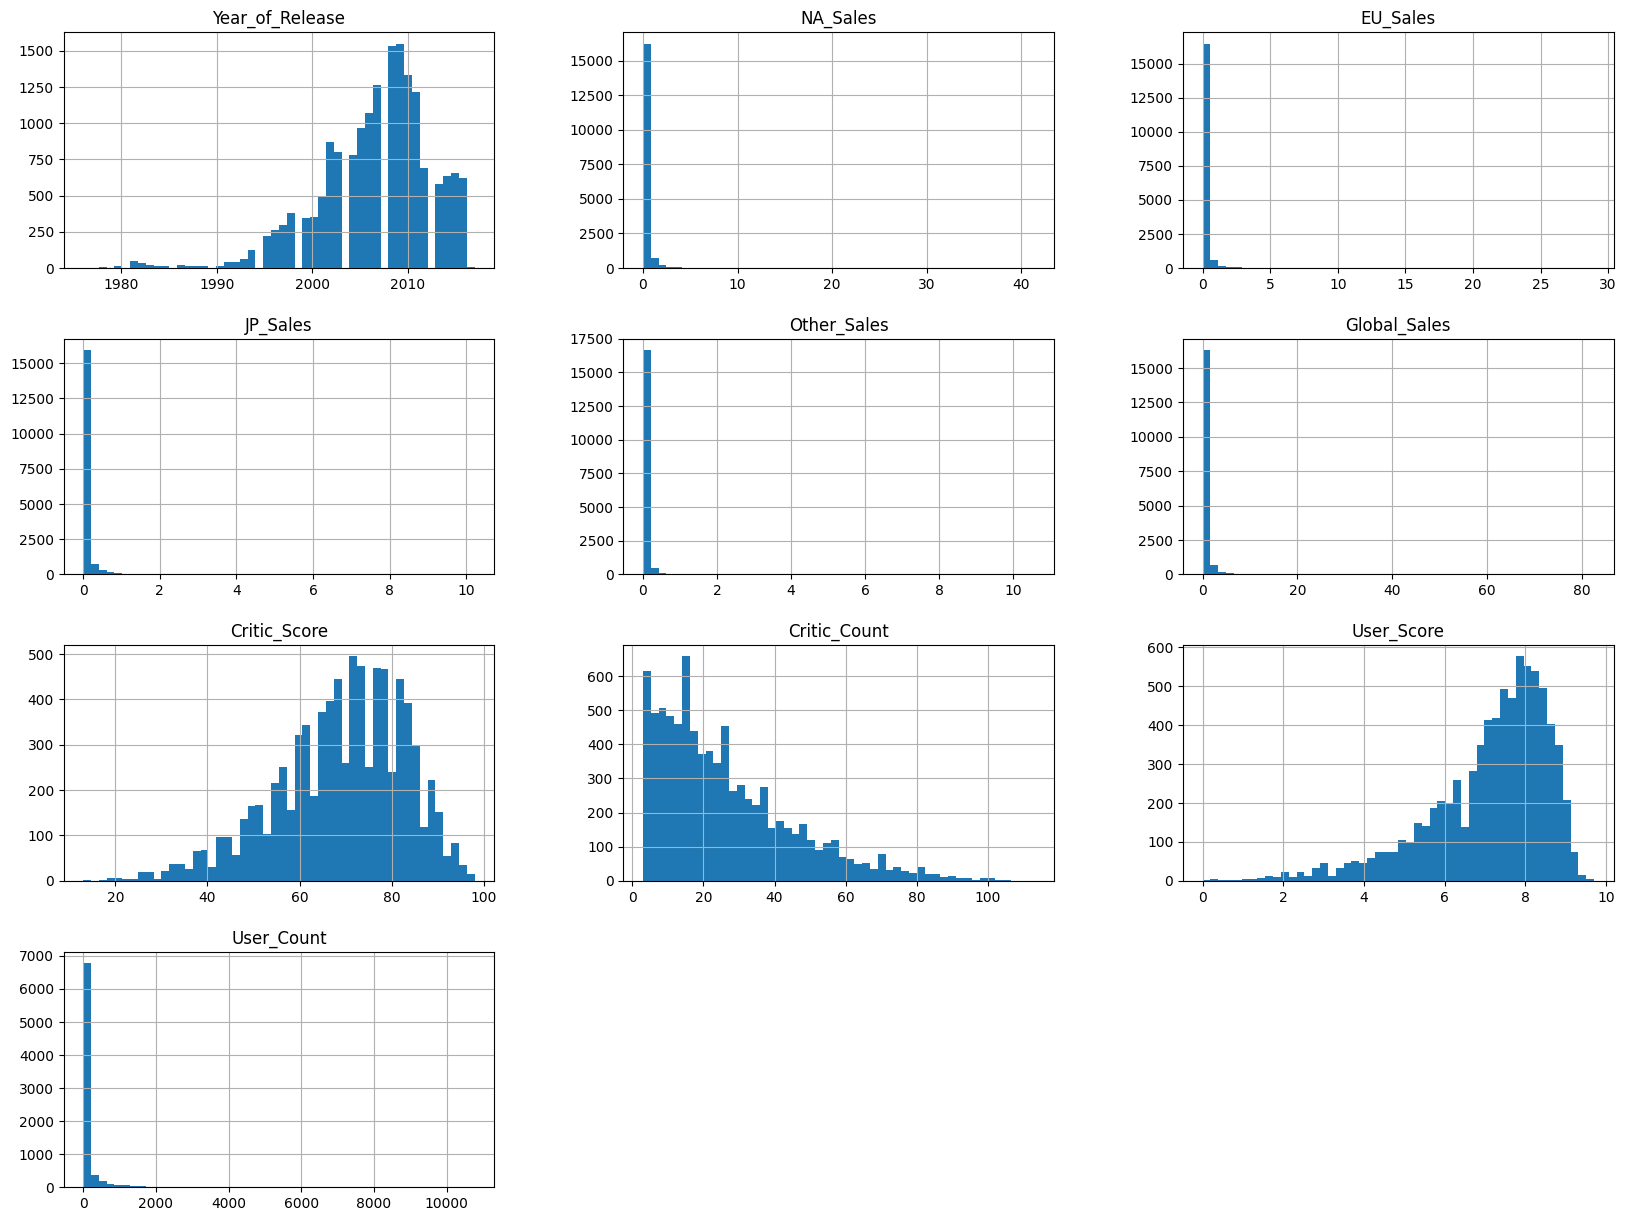

In [81]:
%matplotlib inline
import matplotlib.pyplot as plt
fred.hist(bins=50, figsize=(20,15))
plt.show()

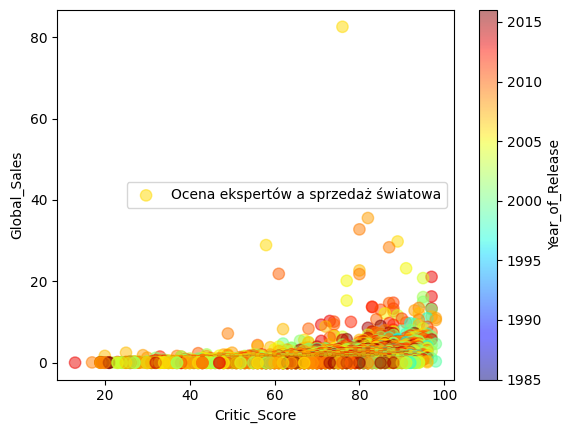

In [82]:
fred.plot(kind="scatter", x="Critic_Score", y="Global_Sales", alpha=0.5,
s=fred["Year_of_Release"]/30, label="Ocena ekspertów a sprzedaż światowa",
c="Year_of_Release", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.show()

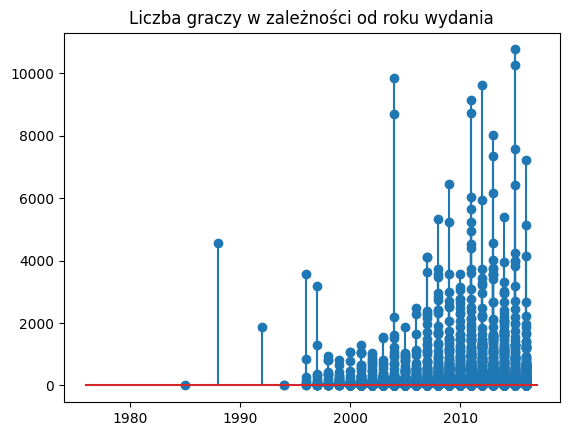

In [83]:
plt.stem(fred["Year_of_Release"], fred["User_Count"])
plt.title("Liczba graczy w zależności od roku wydania")
plt.show()

KORELACJE

In [84]:
attributes = ["Critic_Score", "Global_Sales", "Year_of_Release"]
fred[attributes].corr()

,Critic_Score,Global_Sales,Year_of_Release
Critic_Score,1.000000,0.245523,0.010899
Global_Sales,0.245523,1.000000,-0.079628
Year_of_Release,0.010899,-0.079628,1.000000


In [85]:
numeric_cols = fred.select_dtypes(include=['number']).columns

correlations_with_Global_Sales = fred[numeric_cols].corr()['Global_Sales'].sort_values(ascending=False)

display(correlations_with_Global_Sales)

,Global_Sales
Global_Sales,1.000000
NA_Sales,0.941072
EU_Sales,0.901681
Other_Sales,0.751348
JP_Sales,0.613325
Critic_Count,0.307431
User_Count,0.266895
Critic_Score,0.245523
User_Score,0.087241
Year_of_Release,-0.079628


Uzupełnianie pustych wartości (NaN) w df

In [86]:
#Już przy pierwszym fred.info nie wyświetlały mi się żadne nulle w Non-Null Count,
#ale i tak było je widać przy fred.head(), więc i tak spróbowałam usunąć NaN w całym df

numeric_cols = fred.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if fred[col].isnull().any():
        median_value = fred[col].median()
        fred[col] = fred[col].fillna(median_value)
        print(f"'{col}' mediana: {median_value}")


object_cols = fred.select_dtypes(include=['object']).columns
for col in object_cols:
    if fred[col].isnull().any():
        mode_value = fred[col].mode()[0]
        fred[col] = fred[col].fillna(mode_value)
        print(f"'{col}' moda: {mode_value}")

fred.info()

'Year_of_Release' mediana: 2008.0
'Critic_Score' mediana: 71.0
'Critic_Count' mediana: 21.0
'User_Score' mediana: 7.5
'User_Count' mediana: 25.0
'Publisher' moda: Electronic Arts
'Rating' moda: E
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17416 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17416 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     17416 non-null  float64
 11  Critic_Count     17416 non-null  float64
 12  User_Score       17416 non-null  float64
 13  

In [87]:
fred.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,71.0,21.0,7.5,25.0,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,71.0,21.0,7.5,25.0,E


In [88]:
#usunęłam kolumnę Name
fred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17416 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17416 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     17416 non-null  float64
 11  Critic_Count     17416 non-null  float64
 12  User_Score       17416 non-null  float64
 13  User_Count       17416 non-null  float64
 14  Rating           17416 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB


One Hot Encoding na kolumnach typu object

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_attribs = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Year_of_Release']
cat_attribs = ["Platform", "Genre", "Publisher", "Rating"]

num_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy="median")),
  ('std_scaler', StandardScaler())])

cat_pipeline = Pipeline([
  ('one_hot', OneHotEncoder(handle_unknown='ignore'))])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)])

fred_prepared = full_pipeline.fit_transform(fred)

fred_prepared.shape


(17416, 688)

In [90]:
# Wybór kolumn typu object (kategorialnych) do one-hot encodingu
objecty = fred.select_dtypes(include=['object']).columns

print(f"{list(objecty)}") #Kategorialne kolumny dla pewności, że złapało wszystkie

# Zastosowanie one-hot encodingu
fred_encoded = pd.get_dummies(fred, columns=objecty, drop_first=True)
# drop_first=True, żeby nie tworzyć niepotrzebnie dodatkowej kolumny

display(fred_encoded.head())

fred_encoded.info()

['Name', 'Platform', 'Genre', 'Publisher', 'Rating']


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Publisher_inXile Entertainment,"Publisher_mixi, Inc",Publisher_responDESIGN,Rating_E,Rating_E10+,Rating_EC,Rating_K-A,Rating_M,Rating_RP,Rating_T
0,2006.0,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,...,False,False,False,True,False,False,False,False,False,False
1,1985.0,29.08,3.58,6.81,0.77,40.24,71.0,21.0,7.5,25.0,...,False,False,False,True,False,False,False,False,False,False
2,2008.0,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,...,False,False,False,True,False,False,False,False,False,False
3,2009.0,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,...,False,False,False,True,False,False,False,False,False,False
4,1996.0,11.27,8.89,10.22,1.00,31.37,71.0,21.0,7.5,25.0,...,False,False,False,True,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Columns: 12763 entries, Year_of_Release to Rating_T
dtypes: bool(12753), float64(10)
memory usage: 213.1 MB


In [91]:
#sprawdzenie średniej Global Sales dla upewnienia się, że skalowanie się powiodło
średnia_Y = fred_Y.mean()
średnia_Y

np.float64(6.201337611135463e-17)

In [92]:
#chcę zobaczyć, czy jest bliska zeru
print(f"Średnia Y w notacji dziesiętnej: {średnia_Y:.20f}")

Średnia Y w notacji dziesiętnej: 0.00000000000000006201


Rozdzielenie zmiennej przewidywanej (Global_Sales) od przewidujących

In [93]:
nazwy_kolumn = full_pipeline.get_feature_names_out()

YGlobal_Sales = 'num__Global_Sales'

try:
    num_Global_Sales_index = list(nazwy_kolumn).index(YGlobal_Sales)
    print(f"'Global_Sales' indeks: {num_Global_Sales_index}")
except ValueError:
    print(f"Błąd")

'Global_Sales' indeks: 4


In [94]:
import numpy as np

if hasattr(fred_prepared, 'toarray'):
    fred_prepared_dense = fred_prepared.toarray()
else:
    fred_prepared_dense = fred_prepared


fred_Y = fred_prepared_dense[:, num_Global_Sales_index]

fred_X = np.delete(fred_prepared_dense, num_Global_Sales_index, axis=1)

print("fred_X:", fred_X.shape)
print("fred_Y:", fred_Y.shape)

fred_X: (17416, 687)
fred_Y: (17416,)


Train-test split

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(fred_X, fred_Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (13932, 687)
X_test: (3484, 687)
Y_train: (13932,)
Y_test: (3484,)


MODEL 1: REGRESJA LINIOWA

In [96]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

LinearRegression()

In [97]:
from sklearn.metrics import mean_squared_error
predykcja = lin_reg.predict(X_train)
lin_mse = mean_squared_error(Y_train, predykcja)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.003312137249722354)

In [98]:
def display_scores(scores):
 print("Scores:", scores)
 print("Mean:", scores.mean())
 print("Standard deviation:", scores.std())

In [99]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, X_train, Y_train, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [0.003273   0.00357744 0.00341305 0.00351591 0.00344672 0.00335034
 0.00336461 0.00340454 0.00350293 0.00355579]
Mean: 0.0034404339339445247
Standard deviation: 9.255369188345281e-05


Odwrócenie skalowania, żeby wiedzieć faktycznie, o ile model się pomylił

In [100]:
std_scaler = full_pipeline.named_transformers_['num'].named_steps['std_scaler']

global_sales_mean = std_scaler.mean_[num_Global_Sales_index]
global_sales_scale = std_scaler.scale_[num_Global_Sales_index]

print(f"Średnia dla Global_Sales (przed skalowaniem): {global_sales_mean:.4f}")
print(f"Odchylenie standardowe dla Global_Sales (przed skalowaniem): {global_sales_scale:.4f}")

Średnia dla Global_Sales (przed skalowaniem): 0.5165
Odchylenie standardowe dla Global_Sales (przed skalowaniem): 1.5261


In [101]:
lin_rmse_original_scale = lin_rmse * global_sales_scale
print(f"RMSE dla całego zbioru danych (w oryginalnej skali Global_Sales): {lin_rmse_original_scale:.4f}")

lin_rmse_scores_original_scale = lin_rmse_scores * global_sales_scale
print("\nWyniki cross-walidacji RMSE (w oryginalnej skali Global_Sales):")
display_scores(lin_rmse_scores_original_scale)

RMSE dla całego zbioru danych (w oryginalnej skali Global_Sales): 0.0051

Wyniki cross-walidacji RMSE (w oryginalnej skali Global_Sales):
Scores: [0.00499486 0.00545947 0.00520859 0.00536557 0.00525997 0.00511288
 0.00513467 0.00519561 0.00534576 0.00542643]
Mean: 0.0052503788924038
Standard deviation: 0.00014124437777585336


### Ocena modelu na zbiorze testowym

In [102]:
predykcja_test = lin_reg.predict(X_test)

lin_mse_test = mean_squared_error(Y_test, predykcja_test)
lin_rmse_test = np.sqrt(lin_mse_test)
print(f"RMSE na przeskalowanym zbiorze testowym: {lin_rmse_test:.4f}")

lin_rmse_test_original_scale = lin_rmse_test * global_sales_scale
print(f"RMSE na zbiorze testowym (w oryginalnej skali Global_Sales): {lin_rmse_test_original_scale:.4f}")


RMSE na przeskalowanym zbiorze testowym: 0.0034
RMSE na zbiorze testowym (w oryginalnej skali Global_Sales): 0.0052


MODEL 2: RANDOM FOREST REGRESSOR

In [103]:
from sklearn.ensemble import RandomForestRegressor

In [104]:
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, Y_train)

las = forest_reg.predict(X_train)
forest_mse = mean_squared_error(Y_train, las)
forest_rmse = np.sqrt(forest_mse)

forest_rmse

np.float64(0.10539753313833547)

In [105]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(forest_reg, X_train, Y_train,
scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-scores)

In [106]:
display_scores(forest_rmse_scores)

Scores: [0.86956848 0.16820178 0.09496406 0.10413987 0.18761928 0.08058813
 0.20565504 0.11512148 0.22367921 0.06005098]
Mean: 0.21095883177217675
Standard deviation: 0.22586480080009808


Odwrócenie skalowania i cross-walidacja

In [107]:
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, Y_train)

las_trening = forest_reg.predict(X_train)
forest_mse_train = mean_squared_error(Y_train, las_trening)
forest_rmse_train = np.sqrt(forest_mse_train)
print(f"RMSE na przeskalowanym zbiorze treningowym: {forest_rmse_train:.4f}")

RMSE na przeskalowanym zbiorze treningowym: 0.0894


In [108]:
forest_scores = cross_val_score(forest_reg, X_train, Y_train,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_cv = np.sqrt(-forest_scores)

print("Wyniki cross-walidacji RMSE dla RandomForestRegressor (w przeskalowanych jednostkach):")
display_scores(forest_rmse_cv)


Wyniki cross-walidacji RMSE dla RandomForestRegressor (w przeskalowanych jednostkach):
Scores: [0.83943836 0.15307769 0.08638555 0.10267058 0.17121547 0.07518266
 0.18688421 0.10828737 0.17383835 0.07631815]
Mean: 0.19732983930657955
Standard deviation: 0.2177994161446027


Odwracanie skalowania

In [109]:
forest_rmse_cv_original_scale = forest_rmse_cv * global_sales_scale
print("\nWyniki cross-walidacji RMSE dla RandomForestRegressor (w oryginalnej skali Global_Sales):")
display_scores(forest_rmse_cv_original_scale)


Wyniki cross-walidacji RMSE dla RandomForestRegressor (w oryginalnej skali Global_Sales):
Scores: [1.28105045 0.23360886 0.1318313  0.15668356 0.26128858 0.11473479
 0.28520033 0.16525524 0.26529131 0.11646764]
Mean: 0.30114120573995157
Standard deviation: 0.3323794263337051


### Ocena RandomForestRegressor na zbiorze testowym

In [110]:
las_test = forest_reg.predict(X_test)

# Obliczenie RMSE na przeskalowanych danych testowych
forest_mse_test = mean_squared_error(Y_test, las_test)
forest_rmse_test = np.sqrt(forest_mse_test)
print(f"RMSE na przeskalowanym zbiorze testowym: {forest_rmse_test:.4f}")

# Odwrócenie skalowania RMSE na zbiorze testowym do oryginalnej skali Global_Sales
forest_rmse_test_original_scale = forest_rmse_test * global_sales_scale
print(f"RMSE na zbiorze testowym (w oryginalnej skali Global_Sales): {forest_rmse_test_original_scale:.4f}")

RMSE na przeskalowanym zbiorze testowym: 0.1272
RMSE na zbiorze testowym (w oryginalnej skali Global_Sales): 0.1941


A więc Regresja Liniowa lepiej przewiduje niż Random Forest.

Grid Search do Random Forest

In [111]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [112]:
grid_search.best_params_

{'bootstrap': False, 'max_features': 2, 'n_estimators': 10}

In [113]:
grid_search.best_estimator_

RandomForestRegressor(bootstrap=False, max_features=2, n_estimators=10,
                      random_state=42)

Ocena na zbiorze testowym

In [114]:
best_model = grid_search.best_estimator_

In [115]:
test_pred = best_model.predict(X_test)

In [116]:
test_estim = mean_squared_error(Y_test, test_pred)

In [117]:
final_rmse = np.sqrt(test_estim)
final_rmse

np.float64(0.3445834021519512)

In [118]:
final_rmse_original_scale = final_rmse * global_sales_scale
print(f"RMSE dla Random Forest z hiperparametrami (w oryginalnej skali Global_Sales): {final_rmse_original_scale:.4f}")

RMSE dla Random Forest z hiperparametrami (w oryginalnej skali Global_Sales): 0.5259


Nawet po Grid Search, Regresja Liniowa przewiduje z dużo mniejszym RMSE.
Regresja Liniowa: RMSE = 0.0052
Random Forest: RMSE = 0.5259